# Simulating Superfluous Crossfeeding
The toy model community, displayed below, simulates bacteria in co-culture feeding on seperate media metabolites. An additional metabolite is provided in the media, but only organism 1 is able to metabolize this nutrient into a consumable metabolite for organism 2. 

This interaction is superfluous as it provides no direct benefit (biomass growth) to organism 1, but mathematically will be optimized to maximize total community growth. 

![Superfluous Crossfeeding Microbes](../../figures/toy_model_figs/network_diagrams/4_2_superfluous_crossfeed_diagram.svg)

The following notebook will simulate co-culture of this toy model community, using:
- giFBA
- FBA
- MICOM
- compartmentalized FBA

Followed by comparison of all methods

In [1]:
import gifba
import cobra as cb
from micom import Community
import matplotlib.pyplot as plt
from cobra import Model
import pandas as pd
import numpy as np
import optlang

## Greedy Interaction FBA

In [2]:
import gifba
import cobra as cb
import pandas as pd

# load models
CD_path = "data/Clostridium_difficile_R20291.mat"
CH_path = "data/Clostridium_hiranonis_TO_931_DSM_13275.mat"
BT_path = "data/Bacteroides_thetaiotaomicron_3731.mat"
EL_path = "data/Eggerthella_lenta_DSM_11767.mat"

CD = cb.io.load_matlab_model(CD_path)
CH = cb.io.load_matlab_model(CH_path)
BT = cb.io.load_matlab_model(BT_path)
EL = cb.io.load_matlab_model(EL_path)

ids_list = ["CD", "CH", "BT", "EL"]
paths_list = [CD_path, CH_path, BT_path, EL_path]
rel_abund = [0.1, 0.3, 0.3, 0.3]



euro_media = "data/euro_diet.tsv"
euro_media = pd.read_csv(euro_media, sep="\t", header=0, index_col=0).to_dict()
euro_media = euro_media["Flux Value"]
euro_media = {ex.replace("[e]", "(e)"): -flux for ex, flux in euro_media.items()}

# # initialize community
models = [CD, CH, BT, EL]
community = gifba.gifbaObject(models, [euro_media, 0.1], # minimal media
                            rel_abund=[0.1, 0.3, 0.3, 0.3]) # unequal similar to Hromada et al.

for ex, flux in community.media.items():
    if ex not in euro_media:
        print(ex, flux)

euro_media["EX_cobalt2(e)"] = -1000 #cobalt
euro_media["EX_so4(e)"] = -1000 # sulfate
euro_media["EX_adn(e)"] = -1000 #Adenosine
euro_media["EX_cytd(e)"] = -1000 # cytidine
euro_media["EX_thymd(e)"] = -1000 # thymidine
euro_media["EX_hspg(e)"] = -1 # Heparan Sulfate Proteoglycan
euro_media["EX_26dap_M(e)"] = -10 # Meso-2,6-Diaminoheptanedioate
euro_media["EX_cgly(e)"] = -1000 # Cysteinylglycine - dipep
euro_media["EX_glyasn(e)"] = -1000 # Glycylasparagine - dipep
euro_media["EX_nmn(e)"] = -1000 # Nicotinamide ribotide
euro_media["EX_pheme(e)"] = -1000 #p heme
euro_media["EX_sheme(e)"] = -1000 # s heme
euro_media["EX_spmd(e)"] = -1000 # spermidine




Set parameter Username
Set parameter LicenseID to value 2773321
Academic license - for non-commercial use only - expires 2027-02-01


No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e
No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e
No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e, p
No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e


Read LP format model from file /tmp/tmp_bdonpgl.lp
Reading time = 0.00 seconds
: 1194 rows, 2808 columns, 11912 nonzeros
Read LP format model from file /tmp/tmpksn6gcj4.lp
Reading time = 0.00 seconds
: 953 rows, 1980 columns, 8492 nonzeros
Read LP format model from file /tmp/tmpn6n6_gro.lp
Reading time = 0.00 seconds
: 1318 rows, 3010 columns, 11452 nonzeros
Read LP format model from file /tmp/tmpxkn7vzxz.lp
Reading time = 0.00 seconds
: 1184 rows, 2326 columns, 10388 nonzeros
EX_cobalt2(e) -0.0007939700000179073
EX_so4(e) -0.00079397
EX_adn(e) -0.04417410000007749
EX_cytd(e) -0.02837029998863727
EX_thymd(e) -0.0011746999999786567
EX_hspg(e) -6.616416666638082e-05
EX_26dap_M(e) -0.03104510000002847
EX_cgly(e) -0.00730505000001358
EX_glyasn(e) -0.593552355500151
EX_nmn(e) -0.0006193000001530891
EX_pheme(e) -0.0003096499999628577
EX_sheme(e) -0.0003096499999628577
EX_spmd(e) -0.0003096499999628577


In [ ]:
# initialize community
community = gifba.gifbaObject(models, 
                              euro_media,
                              rel_abund=rel_abund)
# # run iterations
media_flux, org_flux = community.run_gifba(iters=5, 
                                           method="pfba",
                                           v=True) 

summary = community.summarize() # UNCOMMENT TO SEE RESULTS
edges, nodes = community.to_cytoscape()
edges.to_csv("../figures/real_model_figs/cytoscape_networks/CD_comm_edges.csv", index=False)
nodes.to_csv("../figures/real_model_figs/cytoscape_networks/CD_comm_nodes.csv", index=False)

Read LP format model from file /tmp/tmpstfli5pj.lp
Reading time = 0.00 seconds
: 1194 rows, 2808 columns, 11912 nonzeros
Read LP format model from file /tmp/tmptbeyi3_z.lp
Reading time = 0.00 seconds
: 953 rows, 1980 columns, 8492 nonzeros
Read LP format model from file /tmp/tmp1fxb5cjs.lp
Reading time = 0.00 seconds
: 1318 rows, 3010 columns, 11452 nonzeros
Read LP format model from file /tmp/tmpv5_9gcby.lp
Reading time = 0.00 seconds
: 1184 rows, 2326 columns, 10388 nonzeros

Iteration: 0
EX_ribflv(e) over-consumed by factor of 2.024299170877 (rerun count: 0)
EX_pydx(e) over-consumed by factor of 1.420908522259 (rerun count: 2)
EX_cu2(e) over-consumed by factor of 1.091249751326 (rerun count: 4)
EX_his_L(e) over-consumed by factor of 1.002511107755 (rerun count: 6)

Iteration: 1
EX_ribflv(e) over-consumed by factor of 2.024299170877 (rerun count: 0)
EX_pydx(e) over-consumed by factor of 1.420908522259 (rerun count: 2)
EX_cu2(e) over-consumed by factor of 1.091249751326 (rerun count: 

Metabolite,Exchange,Flux,C-Number,C-Flux
ca2[e],EX_ca2(e),0.035675,0,0.00%
fe2[e],EX_fe2(e),0.071813,0,0.00%
tyr_L[e],EX_tyr_L(e),1.168436,9,1.10%
26dap_M[e],EX_26dap_M(e),1.333615,7,0.97%
cu2[e],EX_cu2(e),0.035675,0,0.00%
fol[e],EX_fol(e),0.000135,19,0.00%
thr_L[e],EX_thr_L(e),4.428040,4,1.85%
fru[e],EX_fru(e),2.361308,6,1.48%
pnto_R[e],EX_pnto_R(e),0.003808,9,0.00%
zn2[e],EX_zn2(e),0.035675,0,0.00%


## Simple FBA
Use COBRApy to simulate individual microbes' growth capability

In [ ]:
# # run simulation to compare with COBRApy FBA
fba_results = {}
for idx, model in enumerate(models):
    with model as mdl:
        for ex, flux in euro_media.items():
            if ex in mdl.exchanges:
                mdl.exchanges.get_by_id(ex).lower_bound = flux
        fba = mdl.optimize().objective_value
        print(f"Model {ids_list[idx]} FBA: {fba}")
        fba_results[ids_list[idx]] = fba

Model CD FBA: 0.8038374978509643
Model CH FBA: 0.23646081183750992
Model BT FBA: 4.493235781573284
Model EL FBA: 0.014490961919005329


## Compartmentalized FBA

### Finding the cFBA Pareto-Optimal Points
Since cFBA relies on the Multi-Objective Optimization, the following code is used to identify/estimate the Pareto Frontier. This is done via the following procedure:
1) Maximize Total Biomass
2) Constrain total biomass to maximum
3) Maximize Organism 1 biomass growth
4) Minimize Organism 1 biomass growth
5) Create Set of n-points ranging from Min to Max
6) Constrain organism 1 growth to one value in set (Step 5)
7) Maximize Organism 1 biomass growth
8) Minimize Organism 1 biomass growth
9) Repeat 6-8 for all points in set (Step 5)

In [5]:
cfba_model, micom_comm, objective_dict = gifba.utils.prep_micom_cfba("compartmentalized_model", ids_list, paths_list, rel_abund=rel_abund)

# reset all exchanges
for exchange in cfba_model.exchanges:
    cfba_model.reactions.get_by_id(exchange.id).upper_bound = 1000
    cfba_model.reactions.get_by_id(exchange.id).lower_bound = -1000 if len(exchange.metabolites) > 1 else 0

# set media bounds
media_tmp = {rxn_id.replace("(e)", "_m"): flux for rxn_id, flux in euro_media.items()}
for rxn in cfba_model.reactions:
    if rxn.id in media_tmp:
        # print(f"Setting bounds for {rxn.id}: {media_tmp[rxn.id]}")
        cfba_model.reactions.get_by_id(rxn.id).lower_bound = media_tmp[rxn.id]

#  Optimize compartmentalized model for (optimal) community growth 
solution = cfba_model.optimize()
print(f"{cfba_model.id}, Objective value: {solution.objective_value}")
print(f"Objective Expression: {cfba_model.objective.expression}")

# store growth for each organism
cfba_results = {}
for id in ids_list:
    obj_key = next((k for k in objective_dict.keys() if getattr(k, "id", str(k)).endswith(f"_{id}")), None)
    if obj_key is not None:
        cfba_results[id] = solution.fluxes[obj_key.id]
        print(f"Organism {id} growth: {cfba_results[id]}")
    else:
        print(f"No objective key found for organism {id}")

Output()

No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.

Using regular expression found the following compartments:c, e

No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.

Using regular expression found the following compartments:c, e

...

Using regular expression found the following compartments:c, e, p

No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.

Using regular expression found the following compartments:c, e

Could not identify an external compartment by name and choosing one with the most boundary reactions. That might be complete nonsense or change suddenly. Consider renaming your compartments using `Model.compartments` to fix this.


compartmentalized_model, Objective value: 4.508821911189572
Objective Expression: 0.3*bio1__BT - 0.3*bio1__BT_reverse_caf20 + 0.3*bio1__EL - 0.3*bio1__EL_reverse_f7f72 + 0.1*biomass205__CD - 0.1*biomass205__CD_reverse_8beea + 0.3*biomass525__CH - 0.3*biomass525__CH_reverse_83030
Organism CD growth: 0.0
Organism CH growth: 1.3703393847101357
Organism BT growth: 13.610763779525088
Organism EL growth: 0.048303206396684395


## MICOM
Simulating Community Growth with the MICOM package. A range of tradeoff values are chosen to demonstrate how simulation is affected.

In [6]:
# run with micom
micom_results = pd.DataFrame(columns=["tradeoff", "Org1_growth", "Org2_growth", "Org3_growth", "Org4_growth"])

abund = community.rel_abund.flatten()

# create community dataframe (built above with gifba.utils.prep_micom_cfba())
micom_comm = pd.DataFrame({ 
    "id": ["Org1", "Org2", "Org3", "Org4"],
    "file": paths_list,
    "abundance": abund
})




# # create micom community
micom_comm = Community(micom_comm)
micom_comm.medium = {ex: abs(flux) for ex, flux in media_tmp.items()}
print(f"Micom medium: {micom_comm.medium}")
micom_comm.solver = "gurobi"

# check exchange names and fmedia names
for ex in micom_comm.exchanges:
    print(f"Exchange: {ex.id}, Lower bound: {ex.lower_bound}, Upper bound: {ex.upper_bound}")

solutions = micom_comm.cooperative_tradeoff(fraction=np.linspace(1, 0, 101), pfba=True)
for idx, sol in enumerate(solutions["solution"]):
    print(f"Solution alpha: {solutions['tradeoff'][idx]}", end="  ")
    # print(sol.members)
    org_growth = (sol.members["abundance"] * sol.members["growth_rate"]).to_numpy()[0:-1]
    print(org_growth)
    micom_results.loc[len(micom_results)] = [solutions['tradeoff'][idx], org_growth[0], org_growth[1], org_growth[2], org_growth[3]]


Output()

No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.

Using regular expression found the following compartments:c, e

No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.

Using regular expression found the following compartments:c, e, p

No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.

Using regular expression found the following compartments:c, e

Micom medium: {'EX_ala_L_m': 37.2085636165274, 'EX_arg_L_m': 20.3518771021335, 'EX_asp_L_m': 47.0867491277091, 'EX_btn_m': 0.0001786663279938, 'EX_but_m': 26.3342564399315, 'EX_ca2_m': 18.549079295374, 'EX_cgly_m': 1000, 'EX_cl_m': 375.557498660198, 'EX_cobalt2_m': 1000, 'EX_cu2_m': 0.0356749441349574, 'EX_cys_L_m': 7.5118316383043, 'EX_etoh_m': 234.434015507376, 'EX_fe2_m': 0.109248813680723, 'EX_fe3_m': 0.109248813680723, 'EX_fru_m': 106.505865197865, 'EX_glc_D_m': 135.580350130082, 'EX_glu_L_m': 103.122200527918, 'EX_gly_m': 36.7646862919061, 'EX_glyasn_m': 1000, 'EX_h2o_m': 165892.342500366, 'EX_his_L_m': 14.0240766306639, 'EX_ile_L_m': 28.9216751325922, 'EX_k_m': 83.433806584941, 'EX_lcts_m': 4.12671470494148, 'EX_leu_L_m': 46.8878099058571, 'EX_lys_L_m': 33.3115482470592, 'EX_malt_m': 8.41375824760113, 'EX_met_L_m': 10.7274046938804, 'EX_mg2_m': 14.529932112734, 'EX_mn2_m': 0.07470233059804, 'EX_mnl_m': 0.170169038237532, 'EX_na1_m': 172.446271718304, 'EX_nac_m': 0.30861619226627

# Comparison
Each simulation technique is simulated via plotting expected growth. Organism 1 is plotted on the x-axis and Organism 2 on the y-axis. 

Each color represents a simulation method. 

giFBA is the only iterative method, so all iterates are shown. Circles get smaller as the simulation converges to the final iteration. 

    tradeoff   Org1_growth  Org2_growth  Org3_growth  Org4_growth
0       1.00  2.839451e-13     0.411102     4.083232     0.014488
25      0.75  3.673933e-02     0.373749     2.956637     0.014491
50      0.50  3.861372e-02     0.371844     1.829462     0.014491
75      0.25  4.048810e-02     0.369938     0.702289     0.014491
Model
0    0.234159
1    0.173036
2    4.083229
3    0.014491
Name: EX_biomass(e), dtype: float64
{'CD': 0.8038374978509643, 'CH': 0.23646081183750992, 'BT': 4.493235781573284, 'EL': 0.014490961919005329}
    tradeoff   Org1_growth  Org2_growth  Org3_growth  Org4_growth
0       1.00  2.839451e-13     0.411102     4.083232     0.014488
25      0.75  3.673933e-02     0.373749     2.956637     0.014491
50      0.50  3.861372e-02     0.371844     1.829462     0.014491
75      0.25  4.048810e-02     0.369938     0.702289     0.014491
[0.0, 0.4111018154130407, 4.083229133857526, 0.014490961919005318]

[2.34158616e-01 8.03837498e-01 0.00000000e+00 4.04880998e-02
 3.861

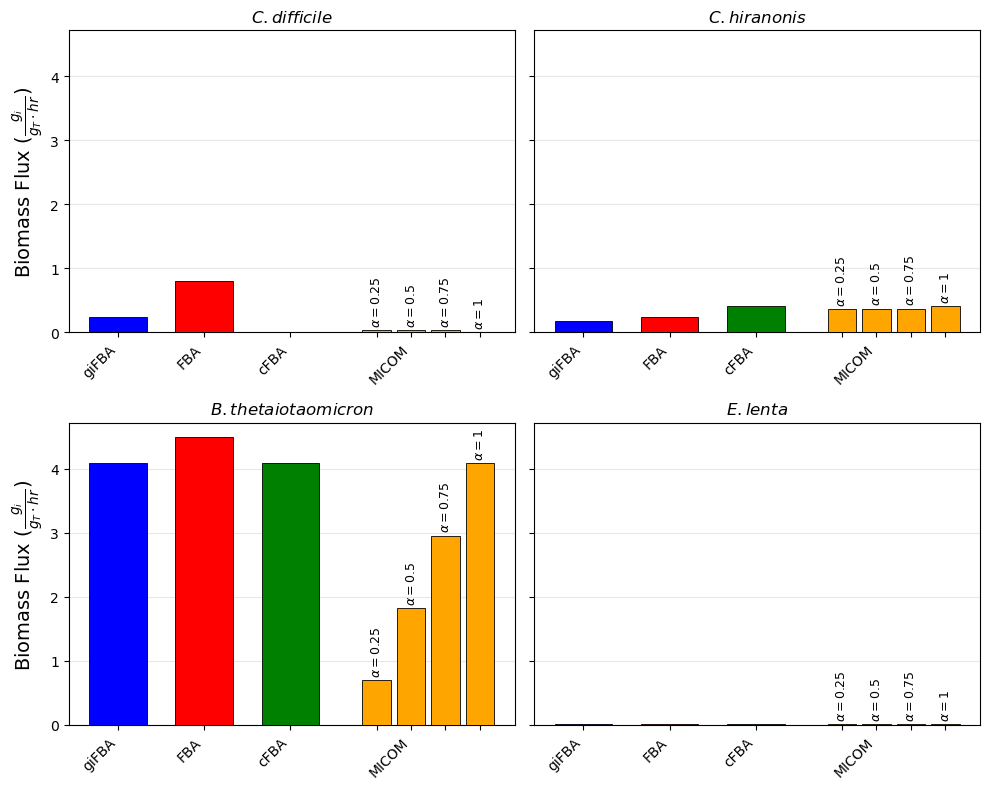

In [10]:
#plot model results
import gifba
import matplotlib.pyplot as plt
import numpy as np

# sizes for markers
fba_marker_size, cfba_marker_size, micom_marker_size = 100, 20, 50
gifba_marker_sizes = np.linspace(18, 4, community.iters)**2 * np.pi
micom_line_width = 0.5
colors = ["b", "r", "g", "orange"] # gifba, FBA, cFBA, MICOM

# extract cumulative growth for each organism
gifba_results = org_flux.loc[:]["EX_biomass(e)"]

# plot giFBA results for each org
fig, axs = plt.subplots(2,2, sharey=True, figsize=(10,8))
axs = axs.flatten()


micom_results = micom_results
micom_tradeoffs = micom_results["tradeoff"]
micom_results = micom_results.loc[micom_tradeoffs.isin([0.25, 0.5, 0.75, 1.0])]
print(micom_results)
# print(cfba_results)
cfba = [v * rel_abund[i] for i, v in enumerate(cfba_results.values())]

print(gifba_results)
print(fba_results)
print(micom_results)
print(cfba)
print()
def draw_ax_bar(num, name):
    cfba_cols = ["First_Org_Flux", "Second_Org_Max_Flux", "3rd_Org_Max_Flux", "4th_Org_Max_Flux"]
    micom_cols = [f"Org{i+1}_growth" for i in range(4)]
    data = np.zeros(7, dtype=float)
    data[:3] = [gifba_results[num], fba_results[ids_list[num]],cfba[num]]
    data[3:] = micom_results[micom_cols[num]].values.flatten()[::-1]
    print(data)
    x = [0,0.75, 1.5, 2.25, 2.55, 2.85, 3.15]
    ax = axs[num]

    ax.bar(
        x[:3], data[:3],
        width=0.5,
        color=colors[:3],
        edgecolor="black",
        linewidth=0.6,
        zorder=3
    )
    ax.bar(
        x[3:], data[3:],
        width=0.25,
        color=colors[3],
        edgecolor="black",
        linewidth=0.6,
        zorder=3
    )

    y_offset = 0.05
    for xi, yi, a in zip(x[3:], data[3:], [0.25, 0.5, 0.75, 1]):
        ax.text(
            xi, yi + y_offset,
            rf"$\alpha={a}$",
            ha="center", va="bottom",
            fontsize=9, color="k", rotation=90
    )

    labels=["giFBA", "FBA", "cFBA", 
       "", "MICOM", "", ""]
    
    axis_lab_size = 14
    ax.set_title(name)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.grid(axis="y", alpha=0.3, zorder=0)
    if num in [0,2]:
        ax.set_ylabel(r"Biomass Flux ($\frac{g_i}{g_T \cdot hr}$)", fontsize=axis_lab_size)


names = [r"$\it{C. difficile}$", r"$\it{C. hiranonis}$", r"$\it{B. thetaiotaomicron}$", r"$\it{E. lenta}$"]
for i, name in enumerate(names):
    draw_ax_bar(i, name)






plt.tight_layout()

plt.savefig("../figures/real_model_figs/paper_figs/3_cdiff_community.svg", bbox_inches='tight')